# An End-to-End Model to predict Telco Customer Churn

This model predicts customer churn from usage, spend, and complaint behavior (`TRAIN.csv` / `TEST.csv`).

**Pipeline:** data prep & cleaning → correlation/VIF data-quality gate → feature engineering → tuned
Logistic Regression + LightGBM → evaluation → SHAP interpretability.

check the `README.md` file for the full write-up. This notebook reproduces the whole pipeline end to end.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_validate
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    accuracy_score, confusion_matrix
)
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
%matplotlib inline

## 2. Load & Clean (Data Prep)

Data anomalies like 1 fully-blank row, 3 rows with negative tenure (bad entries), and missing categorical values.

In [2]:
CATEGORICAL_FEATURES = [
    "Network type subscription in Month 1", "Network type subscription in Month 2",
    "Most Loved Competitor network in in Month 1", "Most Loved Competitor network in in Month 2",
]

def load_and_clean(path, is_train):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(subset=["Customer ID"]).reset_index(drop=True)
    df = df[df["network_age"] >= 0].reset_index(drop=True)  # negative tenure = bad data

    for c in CATEGORICAL_FEATURES:
        df[c] = df[c].fillna("Unknown").replace("0", "Unknown")

    if is_train:
        df["Churn Status"] = df["Churn Status"].astype(int)
    return df

raw_train = load_and_clean("TRAIN.csv", is_train=True)
raw_test = load_and_clean("TEST.csv", is_train=False)
print("Train:", raw_train.shape, " Test:", raw_test.shape)
raw_train.head()

Train: (1397, 16)  Test: (598, 15)


,Customer ID,network_age,Customer tenure in month,Total Spend in Months 1 and 2 of 2017,Total SMS Spend,Total Data Spend,Total Data Consumption,Total Unique Calls,Total Onnet spend,Total Offnet spend,Total Call centre complaint calls,Network type subscription in Month 1,Network type subscription in Month 2,Most Loved Competitor network in in Month 1,Most Loved Competitor network in in Month 2,Churn Status
0,ADF0039,123.0,4.10,76.7140,0.00,1.25,1.4951,14.0,564.0,6408.0,2.0,2G,2G,Uxaa,Mango,0
1,ADF0041,1316.0,43.87,98.8904,4.14,1.25,1.0244,27.0,1626.0,4373.0,1.0,2G,2G,Uxaa,Mango,0
2,ADF0051,2385.0,79.50,372.6300,3.51,1.25,6.0898,119.0,10411.0,22039.0,1.0,2G,2G,Weematel,Mango,0
3,ADF0059,1614.0,53.80,530.2000,6.85,1.25,3.3447,69.0,6822.0,6274.0,1.0,2G,2G,Unknown,Mango,0
4,ADF0060,2175.0,72.50,554.1300,6.99,153.75,673204.0342,33.0,3387.0,7241.0,1.0,2G,3G,Weematel,Mango,0


## 3. Feature Engineering

In [3]:
def engineer_features(df):
    df = df.copy()
    df["Onnet_ratio"] = df["Total Onnet spend"] / (df["Total Onnet spend"] + df["Total Offnet spend"] + 1)
    df["Data_per_Naira"] = df["Total Data Consumption"] / (df["Total Data Spend"] + 1)
    df["Complaint_rate"] = df["Total Call centre complaint calls"] / (df["Customer tenure in month"] + 1)
    return df

train_df = engineer_features(raw_train)
test_df = engineer_features(raw_test)
train_df[["Onnet_ratio", "Data_per_Naira", "Complaint_rate"]].describe()

,Onnet_ratio,Data_per_Naira,Complaint_rate
count,1397.000000,1.397000e+03,1397.000000
mean,0.297553,2.097997e+05,0.123070
std,0.288341,1.082381e+06,0.381641
min,0.000000,2.604444e-02,0.005577
25%,0.018809,1.732209e+02,0.017867
50%,0.216587,6.509158e+03,0.038911
75%,0.508800,6.964893e+04,0.135135
max,0.999853,2.460275e+07,12.039312


## 4. Data Quality Gate: Correlation + VIF

This was a very important stage, before modeling, we automatically:
1. Drop one feature from any pair with |correlation| > 0.90
2. Iteratively drop the highest-VIF numeric feature until every remaining feature has VIF < 10

This caught issues like `network_age` and `Customer tenure in month` being near-identical
(same information in different units)

In [4]:
RAW_NUMERIC_CANDIDATES = [
    "network_age", "Customer tenure in month", "Total Spend in Months 1 and 2 of 2017",
    "Total SMS Spend", "Total Data Spend", "Total Data Consumption", "Total Unique Calls",
    "Total Onnet spend", "Total Offnet spend", "Total Call centre complaint calls",
]
CORR_THRESHOLD = 0.90
VIF_THRESHOLD = 10.0

def drop_high_correlation(df, candidate_cols, threshold=CORR_THRESHOLD):
    corr = df[candidate_cols].corr().abs()
    to_drop = set()
    cols = list(candidate_cols)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1, c2 = cols[i], cols[j]
            if c1 in to_drop or c2 in to_drop:
                continue
            if corr.loc[c1, c2] > threshold:
                print(f"  Dropping '{c2}' -- correlation {corr.loc[c1, c2]:.4f} with '{c1}'")
                to_drop.add(c2)
    return [c for c in candidate_cols if c not in to_drop], corr

def drop_high_vif(df, candidate_cols, threshold=VIF_THRESHOLD):
    cols = list(candidate_cols)
    while True:
        X = df[cols].dropna()
        Xs = StandardScaler().fit_transform(X)
        vifs = [variance_inflation_factor(Xs, i) for i in range(Xs.shape[1])]
        vif_series = pd.Series(vifs, index=cols).sort_values(ascending=False)
        if vif_series.iloc[0] <= threshold or len(cols) <= 1:
            return cols, vif_series
        worst = vif_series.index[0]
        print(f"  Dropping '{worst}' -- VIF {vif_series.iloc[0]:.2f}")
        cols.remove(worst)

candidates = RAW_NUMERIC_CANDIDATES + ["Onnet_ratio", "Data_per_Naira", "Complaint_rate"]
print("Step 1: correlation check")
survivors, corr_matrix = drop_high_correlation(train_df, candidates)

print("\nStep 2: VIF check")
numeric_features, vif_final = drop_high_vif(train_df, survivors)

print("\nFinal numeric features (all pass both checks):")
vif_final.round(2)

Step 1: correlation check
  Dropping 'Customer tenure in month' -- correlation 1.0000 with 'network_age'

Step 2: VIF check

Final numeric features (all pass both checks):


Total Spend in Months 1 and 2 of 2017    6.70
Total Offnet spend                       3.01
Total Data Spend                         2.68
Complaint_rate                           2.20
Total Call centre complaint calls        2.08
Total Unique Calls                       2.01
Total Onnet spend                        1.70
Onnet_ratio                              1.28
Total SMS Spend                          1.27
network_age                              1.26
Total Data Consumption                   1.17
Data_per_Naira                           1.10
dtype: float64

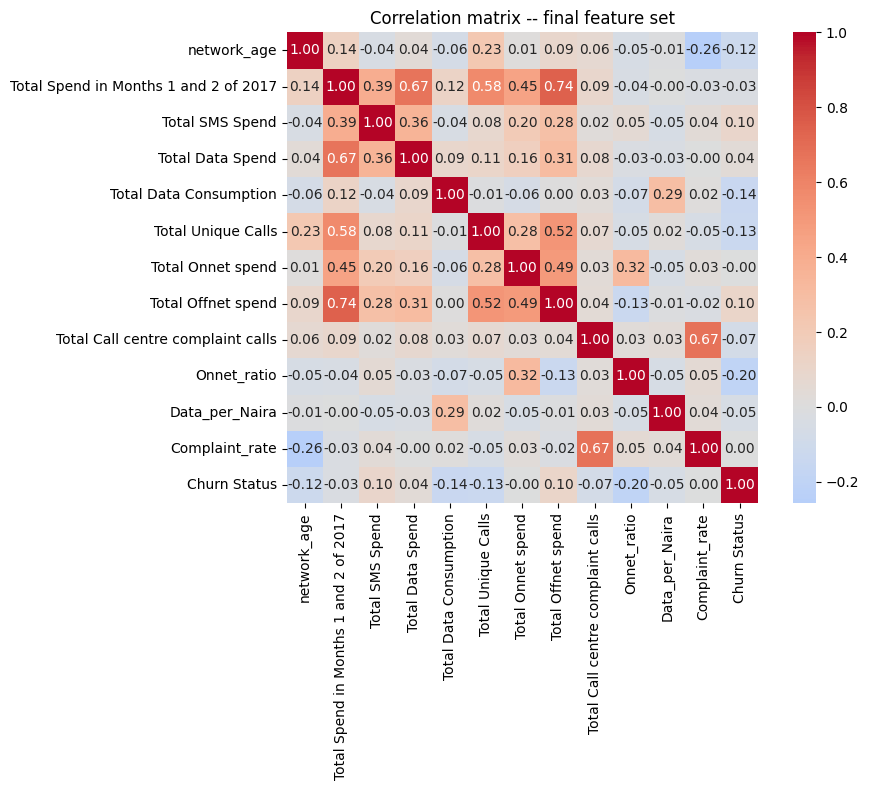

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(train_df[numeric_features + ["Churn Status"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation matrix -- final feature set")
plt.tight_layout()
plt.show()

## 5. Train / Validation Split

In [6]:
all_features = numeric_features + CATEGORICAL_FEATURES
X = train_df[all_features]
y = train_df["Churn Status"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} customers ({y_train.mean():.1%} churn)")
print(f"Val  : {X_val.shape[0]} customers ({y_val.mean():.1%} churn)")

def build_preprocessor(numeric_cols):
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: 1117 customers (49.9% churn)
Val  : 280 customers (50.0% churn)


## 6. Model 1 — Logistic Regression (tuned)

In [7]:
lr_pipe = Pipeline([
    ("prep", build_preprocessor(numeric_features)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE)),
])
lr_search = GridSearchCV(lr_pipe, {"clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
                          scoring="roc_auc", cv=cv, n_jobs=-1)
lr_search.fit(X_train, y_train)
lr_best = lr_search.best_estimator_
print("Best params:", lr_search.best_params_)

Best params: {'clf__C': 0.1}


## 7. Model 2 — LightGBM (tuned)

In [8]:
lgbm_pipe = Pipeline([
    ("prep", build_preprocessor(numeric_features)),
    ("clf", LGBMClassifier(class_weight="balanced", random_state=RANDOM_STATE, verbose=-1)),
])
lgbm_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [3, 4, 5, -1],
    "clf__learning_rate": [0.02, 0.05, 0.1],
    "clf__num_leaves": [15, 31],
}
lgbm_search = GridSearchCV(lgbm_pipe, lgbm_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
lgbm_search.fit(X_train, y_train)
lgbm_best = lgbm_search.best_estimator_
print("Best params:", lgbm_search.best_params_)

Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200, 'clf__num_leaves': 15}


## 8. Evaluation

In [9]:
results = {}
for name, model in [("Logistic Regression", lr_best), ("LightGBM", lgbm_best)]:
    proba = model.predict_proba(X_val)[:, 1]
    pred = model.predict(X_val)
    cv_res = cross_validate(model, X, y, cv=cv, scoring=["roc_auc", "accuracy"])

    print(f"=== {name} ===")
    print(f"Holdout  ROC-AUC: {roc_auc_score(y_val, proba):.3f}  |  Accuracy: {accuracy_score(y_val, pred):.3f}"
          f"  |  PR-AUC: {average_precision_score(y_val, proba):.3f}")
    print(f"CV(5-fold) ROC-AUC: {cv_res['test_roc_auc'].mean():.3f} +/- {cv_res['test_roc_auc'].std():.3f}"
          f"  |  Accuracy: {cv_res['test_accuracy'].mean():.3f} +/- {cv_res['test_accuracy'].std():.3f}")
    print(classification_report(y_val, pred, target_names=["No Churn", "Churn"]))
    print("Confusion matrix:")
    print(confusion_matrix(y_val, pred))
    print()

    results[name] = {"model": model, "cv_auc_mean": cv_res["test_roc_auc"].mean(), "proba": proba}

best_name = max(results, key=lambda k: results[k]["cv_auc_mean"])
best_model = results[best_name]["model"]
print(f"Best model by CV ROC-AUC: {best_name}")

=== Logistic Regression ===
Holdout  ROC-AUC: 0.746  |  Accuracy: 0.689  |  PR-AUC: 0.733
CV(5-fold) ROC-AUC: 0.743 +/- 0.028  |  Accuracy: 0.681 +/- 0.017
              precision    recall  f1-score   support

    No Churn       0.70      0.66      0.68       140
       Churn       0.68      0.72      0.70       140

    accuracy                           0.69       280
   macro avg       0.69      0.69      0.69       280
weighted avg       0.69      0.69      0.69       280

Confusion matrix:
[[ 92  48]
 [ 39 101]]



=== LightGBM ===
Holdout  ROC-AUC: 0.900  |  Accuracy: 0.807  |  PR-AUC: 0.899
CV(5-fold) ROC-AUC: 0.901 +/- 0.016  |  Accuracy: 0.806 +/- 0.021
              precision    recall  f1-score   support

    No Churn       0.83      0.77      0.80       140
       Churn       0.79      0.84      0.81       140

    accuracy                           0.81       280
   macro avg       0.81      0.81      0.81       280
weighted avg       0.81      0.81      0.81       280

Confusion matrix:
[[108  32]
 [ 22 118]]

Best model by CV ROC-AUC: LightGBM


## 9. SHAP — Interpreting the Model

SHAP is applied **after** the model is finalized (see the note in `README.md` on why it's
kept as a separate step rather than merged into the prediction pipeline). We use it here to
identify global churn drivers and generate per-customer explanations.

In [10]:
READABLE_NAMES = {
    "num__network_age": "network age (tenure)",
    "num__Total Spend in Months 1 and 2 of 2017": "total spend (months 1-2)",
    "num__Total SMS Spend": "SMS spend",
    "num__Total Data Spend": "data spend",
    "num__Total Data Consumption": "data consumption",
    "num__Total Unique Calls": "number of unique calls",
    "num__Total Onnet spend": "on-network call spend",
    "num__Total Offnet spend": "off-network call spend",
    "num__Total Call centre complaint calls": "complaint calls",
    "num__Onnet_ratio": "share of spend on-network",
    "num__Data_per_Naira": "data usage per naira spent",
    "num__Complaint_rate": "complaint rate (per month)",
}

def readable(feat_name):
    if feat_name in READABLE_NAMES:
        return READABLE_NAMES[feat_name]
    raw = feat_name.replace("cat__", "")
    return raw.replace("_", " ").replace(" in in ", " in ").lower()

def compute_shap(model_pipeline, X_raw):
    prep = model_pipeline.named_steps["prep"]
    clf = model_pipeline.named_steps["clf"]
    X_transformed = prep.transform(X_raw)
    feature_names = prep.get_feature_names_out()
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_transformed)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    return shap_values, feature_names, X_transformed

shap_values_train, feature_names, X_train_transformed = compute_shap(best_model, X_train)

global_importance = pd.Series(
    np.abs(shap_values_train).mean(axis=0), index=feature_names
).sort_values(ascending=False)
global_importance.index = [readable(f) for f in global_importance.index]
print("Global churn drivers (mean |SHAP value|):")
global_importance.head(10).round(4)

Global churn drivers (mean |SHAP value|):


total spend (months 1-2)                         1.5671
SMS spend                                        0.5410
off-network call spend                           0.3841
on-network call spend                            0.2647
most loved competitor network in month 2 uxaa    0.2552
data consumption                                 0.2127
share of spend on-network                        0.1795
network age (tenure)                             0.1631
number of unique calls                           0.1420
complaint rate (per month)                       0.1216
dtype: float64

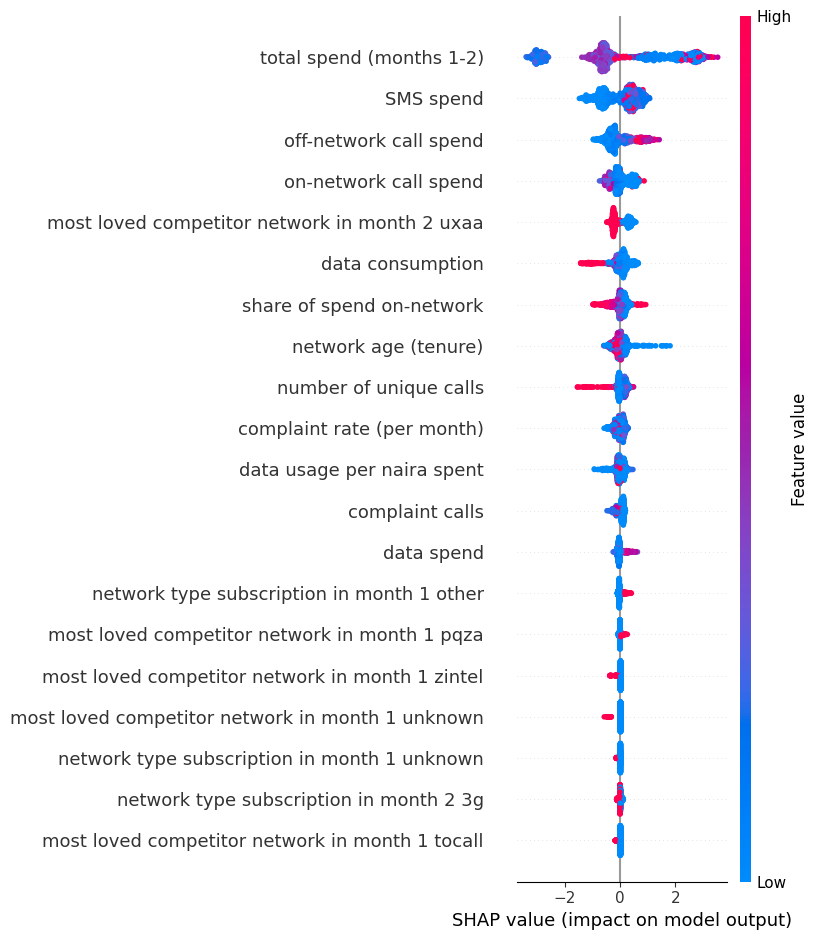

In [11]:
readable_feature_names = [readable(f) for f in feature_names]
shap.summary_plot(shap_values_train, X_train_transformed, feature_names=readable_feature_names)

### Per-customer explanations (top 3 reasons each)

In [12]:
def top_reasons_per_customer(shap_values, feature_names, top_n=3):
    explanations = []
    for row in shap_values:
        order = np.argsort(-np.abs(row))[:top_n]
        parts = [f"{readable(feature_names[i])} {'increases' if row[i] > 0 else 'decreases'} risk" for i in order]
        explanations.append("; ".join(parts))
    return explanations

X_test = test_df[all_features]
shap_values_test, _, _ = compute_shap(best_model, X_test)
test_proba = best_model.predict_proba(X_test)[:, 1]
test_reasons = top_reasons_per_customer(shap_values_test, feature_names)

output = test_df[["Customer ID"]].copy()
output["churn_probability"] = test_proba.round(3)
output["churn_prediction"] = np.where(test_proba >= 0.5, "Yes", "No")
output["top_reasons"] = test_reasons
output = output.sort_values("churn_probability", ascending=False).reset_index(drop=True)
output.head(10)

,Customer ID,churn_probability,churn_prediction,top_reasons
0,ADF0867,0.996,Yes,total spend (months 1-2) increases risk; off-n...
1,ADF0802,0.994,Yes,total spend (months 1-2) increases risk; off-n...
2,ADF0747,0.994,Yes,total spend (months 1-2) increases risk; off-n...
3,ADF0804,0.993,Yes,total spend (months 1-2) increases risk; off-n...
4,ADF0815,0.993,Yes,total spend (months 1-2) increases risk; off-n...
5,ADF0893,0.993,Yes,total spend (months 1-2) increases risk; off-n...
6,ADF0648,0.992,Yes,total spend (months 1-2) increases risk; on-ne...
7,ADF0009,0.992,Yes,total spend (months 1-2) increases risk; off-n...
8,ADF0792,0.992,Yes,total spend (months 1-2) increases risk; off-n...
9,ADF0746,0.992,Yes,total spend (months 1-2) increases risk; off-n...


## 10. Save Final Artifacts

In [13]:
joblib.dump({
    "model": best_model,
    "model_name": best_name,
    "threshold": 0.5,
    "numeric_features": numeric_features,
    "categorical_features": CATEGORICAL_FEATURES,
    "feature_columns": all_features,
    "vif_report": vif_final,
}, "churn_model_final.joblib")

output.to_csv("test_predictions_with_reasons.csv", index=False)
print("Saved churn_model_final.joblib and test_predictions_with_reasons.csv")

Saved churn_model_final.joblib and test_predictions_with_reasons.csv


## 11. Summary

| Model | Holdout ROC-AUC | CV ROC-AUC | CV Accuracy |
|---|---|---|---|
| Logistic Regression | ~0.75 | ~0.74 | ~0.68 |
| **LightGBM (final)** | **~0.90** | **~0.90** | **~0.81** |

Top churn drivers: total spend, SMS spend, off/on-network call spend, competitor preference,
data consumption. See `README.md` for the business interpretation and recommended next steps.